# Customer Churn Prediction — Telecom

**Goal:** identify which telecom customers are likely to leave (churn) so the retention team can contact them *before* they go.

| | |
|---|---|
| **Business problem** | Acquiring a new customer costs far more than keeping an existing one. A model that flags at-risk customers lets the retention team focus offers where they matter. |
| **Data** | IBM *Telco Customer Churn* dataset — 7,043 customers, 21 columns (demographics, services, contract, billing, churn label). |
| **Task** | Binary classification (`Churn` = Yes / No). Only ~27% of customers churn, so the classes are **imbalanced**. |
| **Approach** | Data cleaning → EDA → leak-free preprocessing pipeline → model comparison with cross-validation → tuning → one final evaluation on a held-out test set → interpretation → saved, reusable model. |
| **Main metric** | Recall, precision and F1 on the churn class, plus ROC-AUC / PR-AUC. **Accuracy is *not* used as the headline metric**: predicting "nobody churns" already scores ~73.5%. |

## Results at a glance


| Item | Result |
|---|---|
| **Final model** | Logistic Regression (`class_weight="balanced"`, `C=3`) inside a full preprocessing pipeline |
| **Test-set recall (churn)** | **78%** — 293 of 374 real churners identified |
| **Test-set precision (churn)** | **50%** — about half of the customers flagged are true churners |
| **Test-set F1 / ROC-AUC / PR-AUC** | **0.61 / 0.84 / 0.63** (baseline PR-AUC = 0.27) |
| **Ranking power** | Contacting the **top 30%** of customers by risk score reaches **64%** of all churners (2.2× better than random) |
| **vs. first model (KNN)** | Higher ROC-AUC (0.84 vs 0.83) and PR-AUC (0.63 vs 0.61) with a simpler, interpretable model; KNN was over-flagging customers to get its high recall |
| **Top churn drivers** | Month-to-month contract, short tenure, fiber-optic internet, no tech support / online security, electronic-check payment |


## Table of contents
1. [Setup](#1.-Setup)
2. [Data loading & overview](#2.-Data-loading-&-overview)
3. [Data cleaning](#3.-Data-cleaning)
4. [Exploratory data analysis](#4.-Exploratory-data-analysis)
5. [Train / test split & preprocessing](#5.-Train-/-test-split-&-preprocessing)
6. [Model comparison](#6.-Model-comparison)
7. [Hyperparameter tuning](#7.-Hyperparameter-tuning)
8. [Final evaluation on the test set](#8.-Final-evaluation-on-the-test-set)
9. [Model interpretation](#9.-Model-interpretation)
10. [Error analysis](#10.-Error-analysis)
11. [Save the model & predict for a new customer](#11.-Save-the-model-&-predict-for-a-new-customer)
12. [Conclusions, recommendations & next steps](#12.-Conclusions,-recommendations-&-next-steps)

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             accuracy_score, average_precision_score, classification_report,
                             f1_score, precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
DATA_PATH = Path("data/Telco-Customer-Churn.csv")
MODEL_PATH = Path("models/churn_pipeline.joblib")

## 2. Data loading & overview

Each row is one customer. The target column is `Churn`.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
raw.head()

Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Missing values (NaN):", int(raw.isnull().sum().sum()))
print("Duplicate rows      :", int(raw.duplicated().sum()))
print("Duplicate customerID:", int(raw["customerID"].duplicated().sum()))

Missing values (NaN): 0
Duplicate rows      : 0
Duplicate customerID: 0


**Observations**
- No NaNs and no duplicate rows or customer IDs.
- `TotalCharges` is stored as text (`object`) although it should be numeric — something in it is not a number. This is investigated next.

## 3. Data cleaning

Find out why `TotalCharges` is not numeric.

In [5]:
blank_total = raw["TotalCharges"].str.strip() == ""
print("Rows with blank TotalCharges:", blank_total.sum())
print("Their tenure values          :", raw.loc[blank_total, "tenure"].unique())

Rows with blank TotalCharges: 11
Their tenure values          : [0]


The 11 blank values all belong to customers with `tenure = 0`: they joined this month and have **not been billed yet**. The correct value is therefore `0`, not a missing value to be guessed or dropped.

The target is also encoded as 1 (churned) / 0 (stayed) so it can be used by metrics and models.

In [6]:
df = raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip().replace("", np.nan)).fillna(0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

assert df["customerID"].is_unique
assert df["TotalCharges"].dtype == "float64"
assert df["Churn"].isin([0, 1]).all()
df.dtypes.value_counts()

str        16
int64       3
float64     2
Name: count, dtype: int64

## 4. Exploratory data analysis

EDA is done on the full dataset **only to understand patterns**. No statistics from it are used to fit any model (all fitting happens after the train/test split).

### 4.1 Target distribution

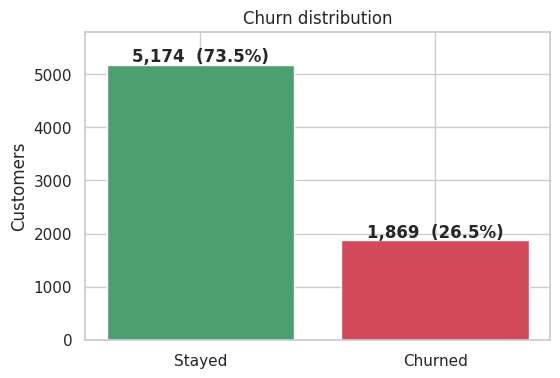

In [7]:
counts = df["Churn"].value_counts().rename({0: "Stayed", 1: "Churned"})
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=["#4C9F70", "#D1495B"])
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + 60, f"{c:,}  ({p:.1f}%)", ha="center", fontweight="bold")
ax.set(title="Churn distribution", ylabel="Customers", ylim=(0, counts.max() * 1.12))
plt.show()

**Insight:** only **26.5%** of customers churn. The dataset is imbalanced, so:
- a model that predicts "no churn" for everyone gets ~73.5% accuracy while being useless → accuracy is misleading;
- splits must be **stratified**, and recall / precision / F1 / PR-AUC are the metrics that matter.

### 4.2 Churn rate by customer segment

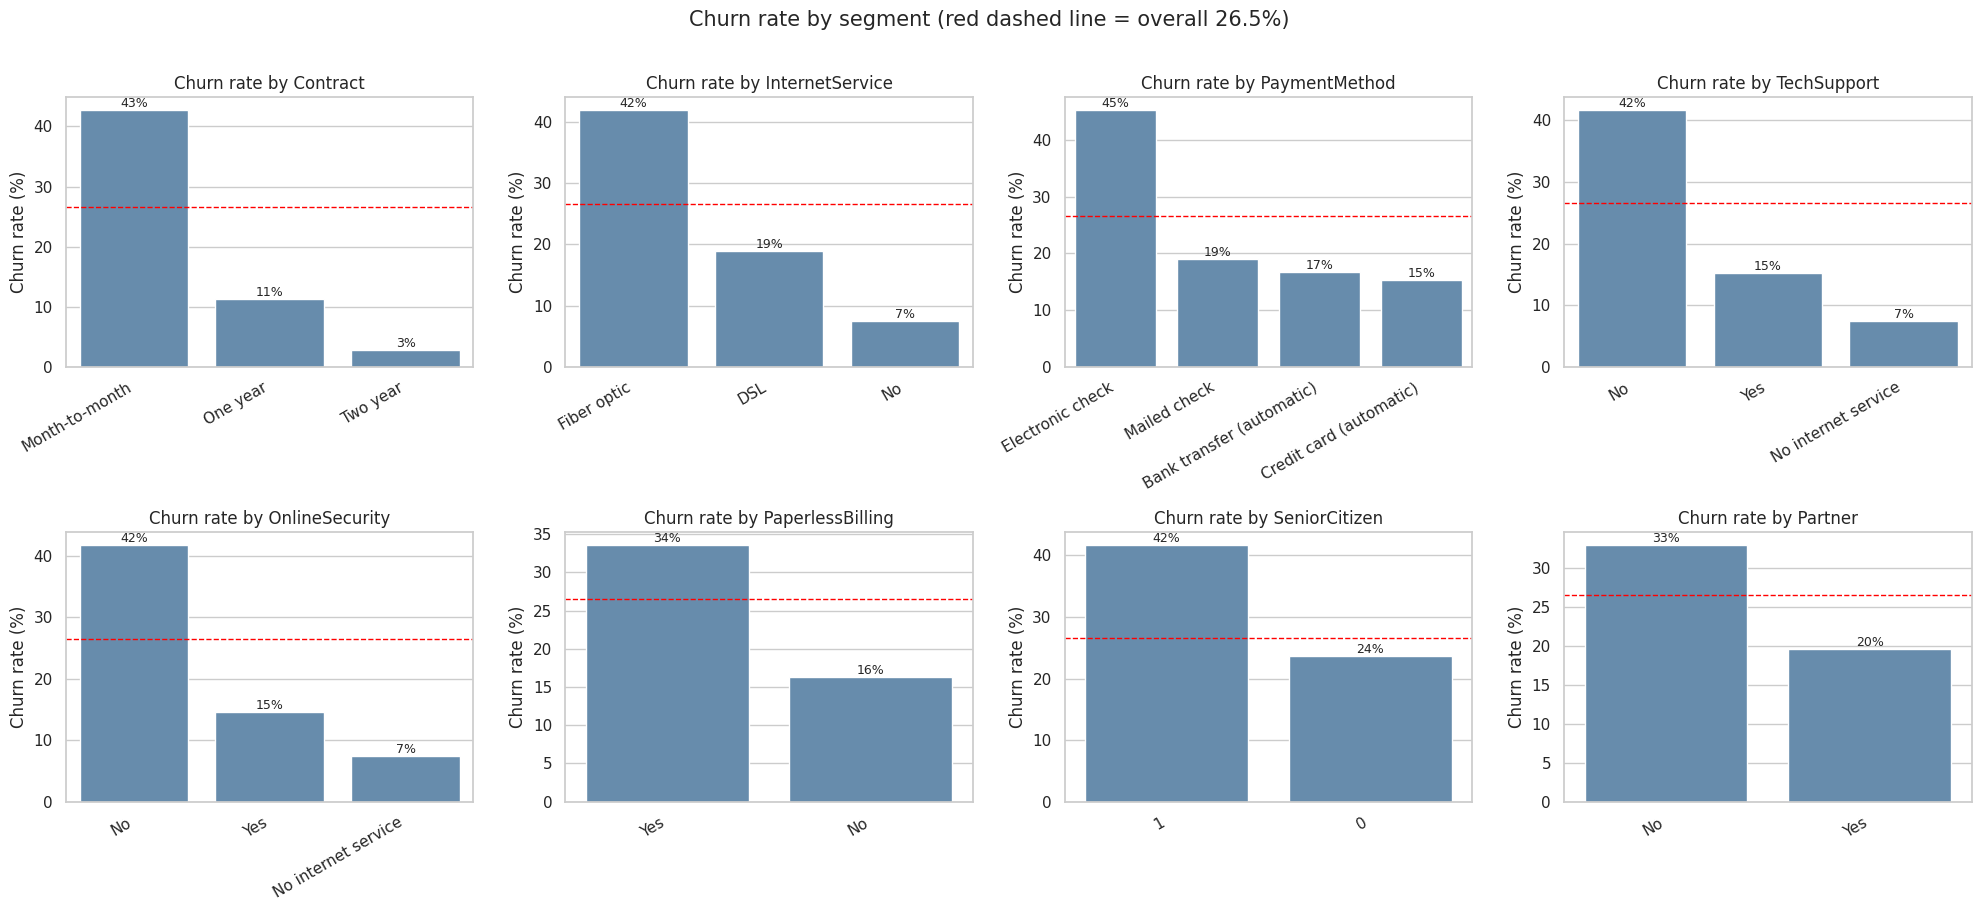

In [8]:
cat_cols_eda = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
                "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner"]
overall = df["Churn"].mean() * 100

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), cat_cols_eda):
    rate = df.groupby(col)["Churn"].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#5B8DB8")
    ax.axhline(overall, color="red", ls="--", lw=1)
    ax.set(title=f"Churn rate by {col}", xlabel="", ylabel="Churn rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
fig.suptitle(f"Churn rate by segment (red dashed line = overall {overall:.1f}%)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Insights**
- **Contract type is the strongest segment signal:** month-to-month customers churn at ~43% versus ~11% (one-year) and ~3% (two-year).
- **Fiber-optic** internet users (~42%, vs ~19% for DSL) and customers paying by **electronic check** (~45%, vs ~15–19% for other methods) churn far more than average.
- Customers **without Tech Support or Online Security** churn much more (~42%) than those who have them (~15%).
- **Senior citizens** churn at ~42% versus ~24% for non-seniors; customers with **partners** (20% vs 33%) or **dependents** (16% vs 31%) churn less.

### 4.3 Tenure (how long the customer has been with the company)

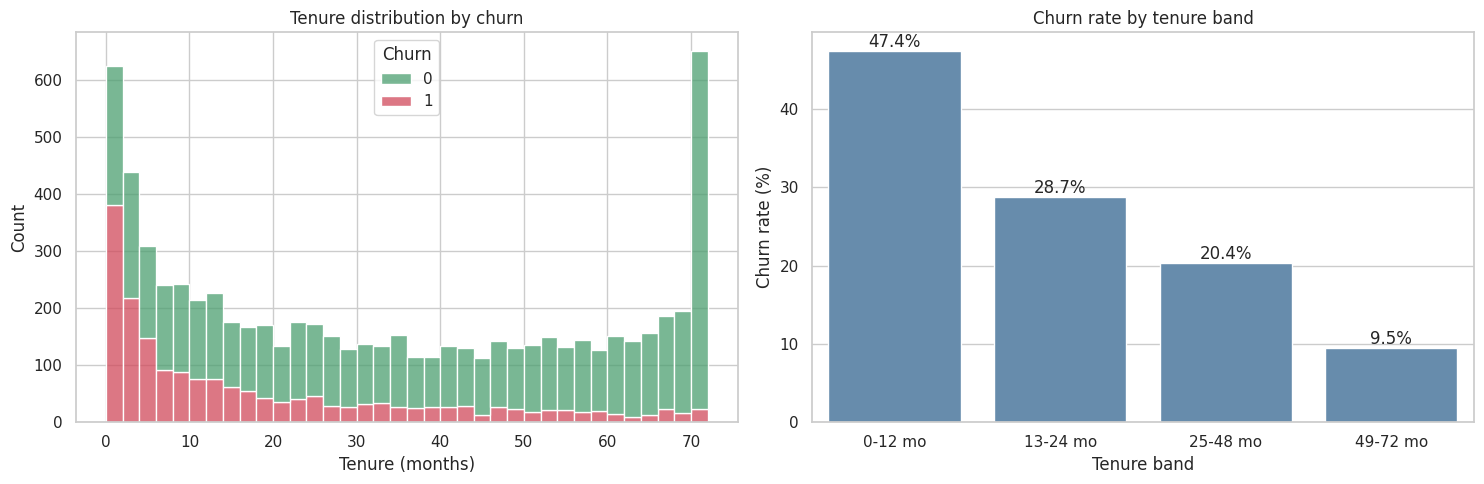

In [9]:
df["tenure_band"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                           labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=36, multiple="stack",
             palette={0: "#4C9F70", 1: "#D1495B"}, ax=axes[0])
axes[0].set(title="Tenure distribution by churn", xlabel="Tenure (months)")

band_rate = df.groupby("tenure_band", observed=True)["Churn"].mean().mul(100)
sns.barplot(x=band_rate.index.astype(str), y=band_rate.values, ax=axes[1], color="#5B8DB8")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom")
axes[1].set(title="Churn rate by tenure band", xlabel="Tenure band", ylabel="Churn rate (%)")
plt.tight_layout()
plt.show()

**Insight:** churn is concentrated in the **first year** (about 47% of customers with ≤12 months of tenure leave, versus ~10% after four years), and falls steadily with tenure. The first months are the critical retention window.

### 4.4 Monthly charges

          mean  median
Churn                 
Stayed   61.27   64.43
Churned  74.44   79.65


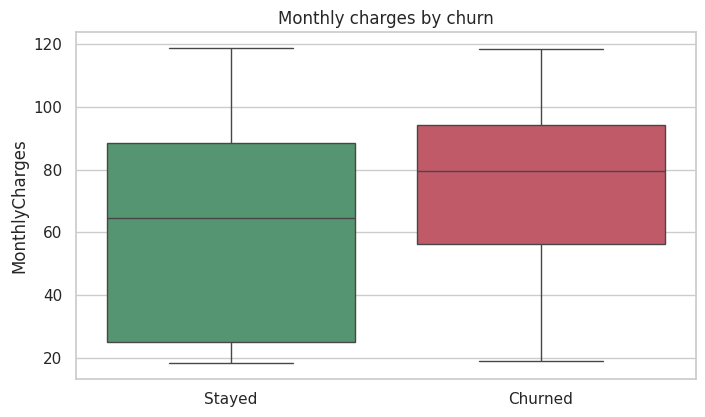

In [10]:
print(df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"]).round(2)
        .rename(index={0: "Stayed", 1: "Churned"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C9F70", "#D1495B"], ax=ax)
ax.set(title="Monthly charges by churn", xticklabels=["Stayed", "Churned"], xlabel="")
plt.show()

**Insight:** churned customers pay more per month on average (~$74 vs ~$61). Higher bills — typically fiber-optic customers with many add-ons — are associated with higher churn.

### 4.5 Correlation between numeric features

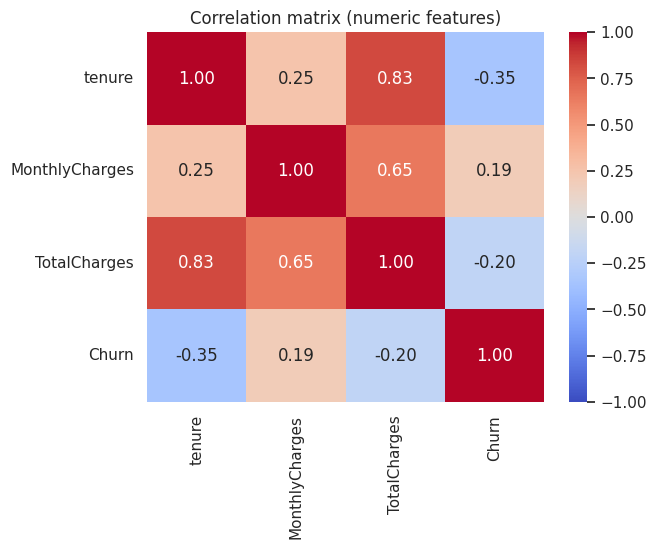

In [11]:
num_corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr().round(2)
sns.heatmap(num_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation matrix (numeric features)")
plt.show()

**Insight:** `tenure` is negatively correlated with churn (longer tenure → less churn). `TotalCharges` is strongly correlated with `tenure` (≈ tenure × monthly price), so it carries partly redundant information — worth remembering when interpreting linear-model coefficients.

## 5. Train / test split & preprocessing

**Design decisions (to avoid data leakage):**
1. The data is split **first**, stratified on `Churn`, so both sets keep the same 26.5% churn rate. 80% is used for training/model selection, 20% is locked away as a **test set that is used exactly once**, at the end.
2. Model selection uses **5-fold stratified cross-validation on the training set only** (no separate hand-made validation split is needed).
3. All preprocessing (scaling, encoding, and SMOTE oversampling where used) lives **inside a scikit-learn `Pipeline`**. It is therefore re-fitted on the training portion of every CV fold and can never see validation/test rows.
4. `customerID` is an identifier, not a feature, and is dropped.

In [12]:
TARGET = "Churn"
df = df.drop(columns=["tenure_band"])          # EDA-only helper column

X = df.drop(columns=["customerID", TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]:,} rows | churn rate {y_train.mean():.1%}")
print(f"Test : {X_test.shape[0]:,} rows | churn rate {y_test.mean():.1%}")

Train: 5,634 rows | churn rate 26.5%
Test : 1,409 rows | churn rate 26.5%


In [13]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]   # incl. 0/1 SeniorCitizen

def make_preprocessor():
    # Scale numeric columns; one-hot encode categoricals (binary columns become a single 0/1 column).
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features),
    ])

print("Numeric    :", numeric_features)
print("Categorical:", len(categorical_features), "columns")

Numeric    : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 16 columns


## 6. Model comparison

Candidates:
- **Dummy** (always predicts "no churn") — the baseline every model must beat.
- **KNN + SMOTE** — the first model built in this project (k = 17, distance-weighted), now evaluated without leakage.
- **Logistic Regression** — simple, fast, interpretable. Class imbalance handled with `class_weight="balanced"`.
- **Random Forest** and **Gradient Boosting** — stronger non-linear models, also class-weighted.

All are compared with the same 5-fold stratified CV on the training set.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

candidates = {
    "Dummy (baseline)": Pipeline([("prep", make_preprocessor()),
        ("clf", DummyClassifier(strategy="most_frequent"))]),
    "KNN + SMOTE": ImbPipeline([("prep", make_preprocessor()), ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", KNeighborsClassifier(n_neighbors=17, weights="distance"))]),
    "Logistic Regression": Pipeline([("prep", make_preprocessor()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", make_preprocessor()),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
                                       random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("prep", make_preprocessor()),
        ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                               class_weight="balanced", random_state=RANDOM_STATE))]),
}

rows = {}
for name, model in candidates.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows[name] = {m: res[f"test_{m}"].mean() for m in scoring}

cv_results = pd.DataFrame(rows).T.round(3).sort_values("pr_auc", ascending=False)
cv_results

,accuracy,precision,recall,f1,roc_auc,pr_auc
Gradient Boosting,0.753,0.523,0.799,0.632,0.848,0.667
Logistic Regression,0.749,0.518,0.803,0.629,0.846,0.660
Random Forest,0.775,0.559,0.730,0.633,0.844,0.656
KNN + SMOTE,0.708,0.470,0.775,0.585,0.796,0.549
Dummy (baseline),0.735,0.000,0.000,0.000,0.500,0.265


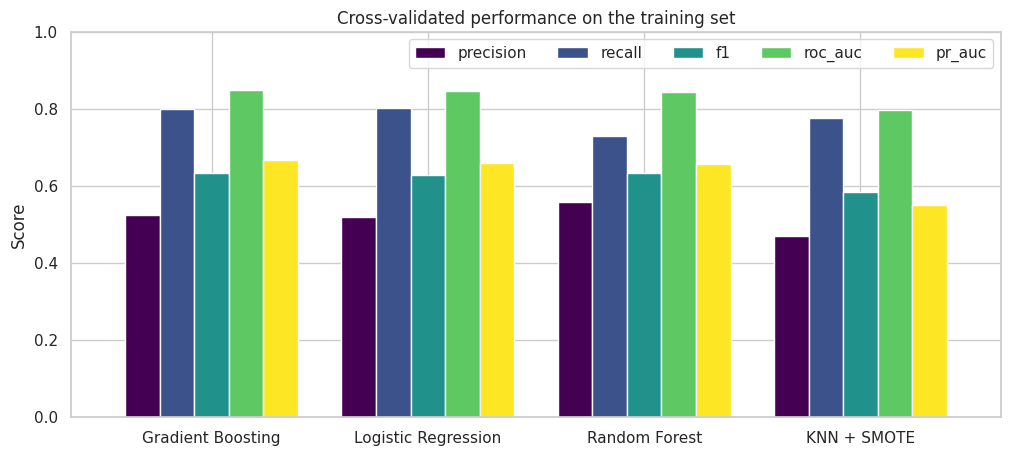

In [15]:
plot_df = cv_results[["precision", "recall", "f1", "roc_auc", "pr_auc"]].drop("Dummy (baseline)")
ax = plot_df.plot(kind="bar", figsize=(12, 5), width=0.8, colormap="viridis")
ax.set(title="Cross-validated performance on the training set", ylabel="Score", ylim=(0, 1))
ax.legend(loc="upper right", ncol=5, frameon=True)
plt.xticks(rotation=0)
plt.show()

**Observations**
- Every real model beats the baseline by a wide margin on PR-AUC (baseline = 0.27, the churn rate).
- **KNN is clearly the weakest** real model (ROC-AUC 0.80 vs ≈0.85, PR-AUC 0.55 vs ≈0.66). KNN suffers from the many one-hot columns (distances become less meaningful) and it is slow at prediction time.
- **Logistic Regression, Random Forest and Gradient Boosting are statistically indistinguishable** (PR-AUC 0.656–0.667, F1 ≈ 0.63). The differences are well inside CV noise.
- **Decision:** with equal performance, pick the **simplest and most interpretable** model — Logistic Regression. It is fast, its coefficients can be explained to business stakeholders, and it is easy to deploy and monitor.

## 7. Hyperparameter tuning

Tune the two models that matter for the story — the original **KNN** and the leading simple model, **Logistic Regression** — with `GridSearchCV` **on the full pipeline** (so SMOTE / scaling are refit inside each fold), optimising **F1 on the churn class**.

In [16]:
knn_grid = GridSearchCV(
    ImbPipeline([("prep", make_preprocessor()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                 ("clf", KNeighborsClassifier())]),
    param_grid={"clf__n_neighbors": [5, 11, 17, 25, 35, 51], "clf__weights": ["uniform", "distance"]},
    scoring="f1", cv=cv, n_jobs=-1)
knn_grid.fit(X_train, y_train)

log_grid = GridSearchCV(
    Pipeline([("prep", make_preprocessor()),
              ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    param_grid={"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    scoring="f1", cv=cv, n_jobs=-1)
log_grid.fit(X_train, y_train)

print(f"KNN + SMOTE          best CV F1 = {knn_grid.best_score_:.3f}  params = {knn_grid.best_params_}")
print(f"Logistic Regression  best CV F1 = {log_grid.best_score_:.3f}  params = {log_grid.best_params_}")

KNN + SMOTE          best CV F1 = 0.602  params = {'clf__n_neighbors': 51, 'clf__weights': 'uniform'}
Logistic Regression  best CV F1 = 0.630  params = {'clf__C': 3}


**Observations**
- Tuning helps KNN noticeably (CV F1 0.585 → 0.602, best at k = 51 with uniform weights: a much smoother model than the k = 5 used at first) but it still trails Logistic Regression (0.630).
- Logistic Regression barely changes with regularisation strength `C` — a sign the linear model is already stable and not overfitting.
- Tuning results come from CV on the training set, so they are slightly optimistic; the honest number is the untouched test set in the next section.

**Threshold trade-off (out-of-fold predictions):**
- At **0.5**: catches ~80% of churners while flagging 41% of customers.
- At **0.4**: catches ~87% of churners but flags ~49% of customers (more retention offers wasted on people who would have stayed).
- At **0.6–0.7**: precision rises to 57–63% but recall falls to 72–59%.
- F1 is almost flat between 0.4 and 0.7, so the *right* threshold depends on business costs (value of a saved customer vs cost of a retention offer), which this dataset does not contain. **0.5 is kept as a neutral default.**

### Choosing the decision threshold

By default a model flags a customer as "churn" when the predicted score is ≥ 0.5. That threshold is really a **business lever**: lowering it catches more churners (higher recall) at the cost of more false alarms (lower precision). The table below uses out-of-fold predictions on the training set to show the trade-off.

In [17]:
best_log = log_grid.best_estimator_
oof_scores = cross_val_predict(best_log, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (oof_scores >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y_train, pred),
                 "recall": recall_score(y_train, pred), "f1": f1_score(y_train, pred),
                 "customers flagged (%)": pred.mean() * 100})
pd.DataFrame(rows).set_index("threshold").round(3)

,precision,recall,f1,customers flagged (%)
threshold,,,,
0.3,0.424,0.926,0.582,57.881
0.4,0.470,0.868,0.610,49.024
0.5,0.518,0.803,0.630,41.108
0.6,0.572,0.719,0.637,33.351
0.7,0.630,0.593,0.611,25.009


## 8. Final evaluation on the test set

The test set has not been touched so far. Both the original model (**KNN + SMOTE**) and the final model (**Logistic Regression**) are refit on the full training set and scored **once** on the test set.

In [18]:
final_models = {
    "KNN + SMOTE (first model)": knn_grid.best_estimator_,
    "Logistic Regression (final)": log_grid.best_estimator_,
}

test_rows, test_scores = {}, {}
for name, model in final_models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    test_scores[name] = (pred, proba)
    test_rows[name] = {"accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
                       "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
                       "roc_auc": roc_auc_score(y_test, proba), "pr_auc": average_precision_score(y_test, proba)}

test_results = pd.DataFrame(test_rows).T.round(3)
test_results

,accuracy,precision,recall,f1,roc_auc,pr_auc
KNN + SMOTE (first model),0.693,0.459,0.874,0.602,0.827,0.608
Logistic Regression (final),0.739,0.505,0.783,0.614,0.841,0.629


In [19]:
final_name = "Logistic Regression (final)"
final_model = final_models[final_name]
final_pred, final_proba = test_scores[final_name]

print(classification_report(y_test, final_pred, target_names=["Stayed", "Churned"], digits=3))

              precision    recall  f1-score   support

      Stayed      0.902     0.723     0.803      1035
     Churned      0.505     0.783     0.614       374

    accuracy                          0.739      1409
   macro avg      0.704     0.753     0.708      1409
weighted avg      0.797     0.739     0.753      1409



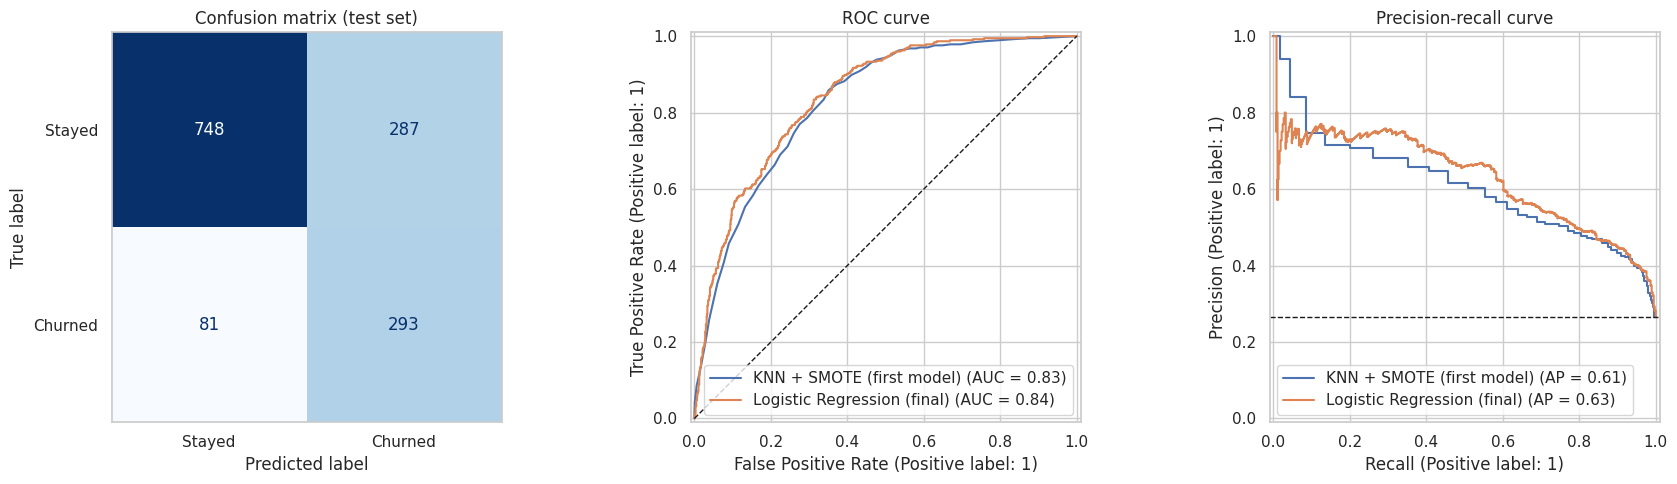

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=["Stayed", "Churned"],
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test set)")
axes[0].grid(False)

for name, (pred, proba) in test_scores.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[2])
axes[1].plot([0, 1], [0, 1], "k--", lw=1); axes[1].set_title("ROC curve")
axes[2].axhline(y_test.mean(), color="k", ls="--", lw=1); axes[2].set_title("Precision-recall curve")
plt.tight_layout()
plt.show()

### Business view: how well does the model rank customers?

If the retention team can only contact a limited number of customers, what share of the real churners does the model put at the top of the list?

In [21]:
rank = pd.DataFrame({"churn": y_test.values, "score": final_proba}).sort_values("score", ascending=False)
total_churners = rank["churn"].sum()

rows = []
for frac in [0.10, 0.20, 0.30, 0.50]:
    top = rank.head(int(len(rank) * frac))
    rows.append({"contact top X% of customers": f"{frac:.0%}",
                 "churners caught (%)": top["churn"].sum() / total_churners * 100,
                 "hit rate in group (%)": top["churn"].mean() * 100,
                 "lift vs random": top["churn"].mean() / y_test.mean()})
pd.DataFrame(rows).set_index("contact top X% of customers").round(1)

,churners caught (%),hit rate in group (%),lift vs random
contact top X% of customers,,,
10%,28.1,75.0,2.8
20%,49.2,65.5,2.5
30%,64.4,57.1,2.2
50%,87.4,46.4,1.7


**Results (test set, threshold 0.5)**
- The final model catches **78% of churners** (293 of 374) at **50% precision**. Test scores are very close to the cross-validated ones (F1 0.61 vs 0.63), which is evidence that the pipeline is **not overfitted and not leaking**.
- The first model (KNN) reaches a higher recall (87%) but only because it flags far more customers (precision 46%). On threshold-independent metrics — **ROC-AUC 0.841 vs 0.827** and **PR-AUC 0.629 vs 0.608** — Logistic Regression ranks customers better.
- **Business meaning:** by contacting the 30% of customers with the highest risk scores, the team reaches ~64% of all churners — 2.2× more efficient than contacting customers at random.

## 9. Model interpretation

### 9.1 Logistic Regression coefficients
Numeric features are standardised, so each coefficient is the change in log-odds per 1 standard deviation (numeric) or versus the reference level (categorical). Positive → raises churn risk; negative → lowers it.

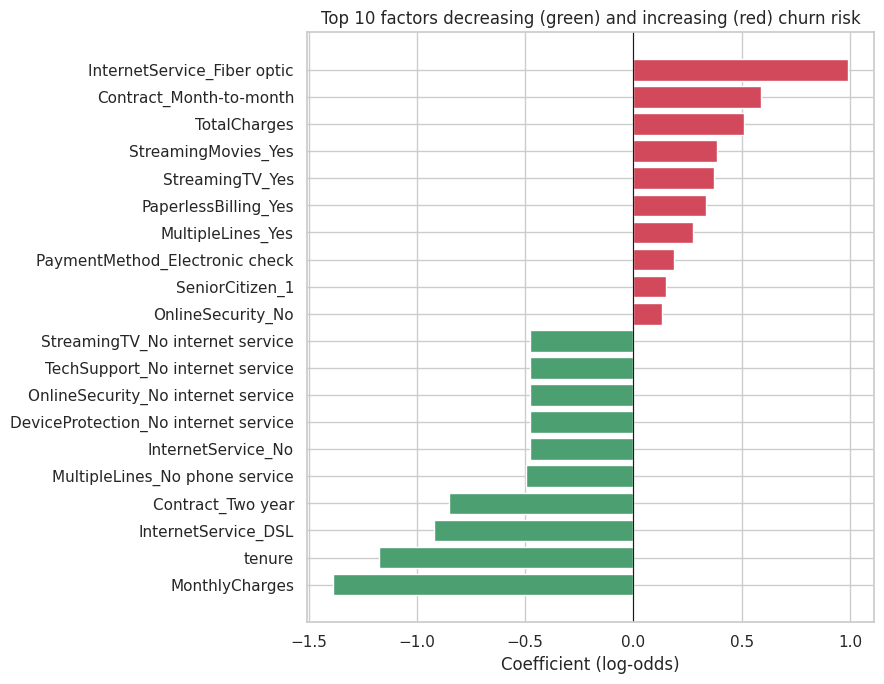

In [22]:
prep = final_model.named_steps["prep"]
feature_names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
coefs = pd.Series(final_model.named_steps["clf"].coef_[0], index=feature_names).sort_values()

top = pd.concat([coefs.head(10), coefs.tail(10)])
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=["#4C9F70" if v < 0 else "#D1495B" for v in top.values])
ax.axvline(0, color="k", lw=0.8)
ax.set(title="Top 10 factors decreasing (green) and increasing (red) churn risk",
       xlabel="Coefficient (log-odds)")
plt.tight_layout()
plt.show()

**Reading the chart**
- **Increase risk:** fiber-optic internet, month-to-month contract, streaming services, paperless billing, electronic-check payment.
- **Decrease risk:** long tenure, two-year contracts, DSL (relative to fiber), and having no internet service.
- ⚠️ **Caution — correlated features:** `MonthlyCharges` has a *negative* coefficient even though churners pay more on average (section 4.4). This is not a contradiction: monthly price is largely the sum of the services a customer has (fiber, streaming, ...), and those service columns already carry the risk. Once they are in the model, extra charge is associated with *lower* risk. Likewise `TotalCharges` ≈ `tenure` × price. Coefficients of highly correlated features should be interpreted as a group, not one by one, and describe **association, not causation**.

### 9.2 Permutation importance (model-agnostic check)
Shuffle one **original** feature at a time on the test set and measure how much PR-AUC drops. A large drop means the model relies on that feature.

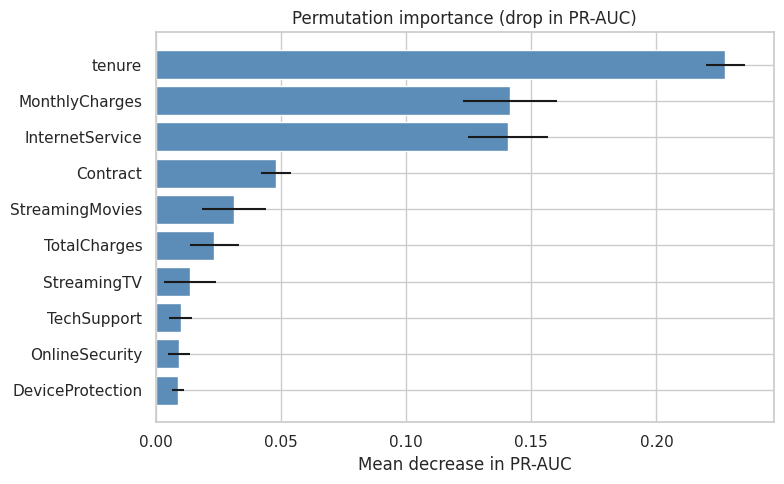

In [23]:
perm = permutation_importance(final_model, X_test, y_test, scoring="average_precision",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_test.columns, "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["importance"], xerr=perm_df["std"], color="#5B8DB8")
ax.set(title="Permutation importance (drop in PR-AUC)", xlabel="Mean decrease in PR-AUC")
plt.tight_layout()
plt.show()

**Observations**
- `tenure`, `MonthlyCharges`, `InternetService` and `Contract` are the features the model relies on most; removing their information hurts performance the most. This agrees with the EDA (section 4) and the coefficients above — three independent views telling the same story is a good sign that the model has learned real patterns and not noise.
- Demographics (gender, partner, dependents) contribute almost nothing.

## 10. Error analysis

Who does the model miss? Compare **missed churners** (false negatives) with **correctly caught churners** (true positives), using the original unscaled values from the test set.

In [24]:
test_view = X_test.copy()
test_view["actual"], test_view["predicted"] = y_test.values, final_pred

fn = test_view[(test_view.actual == 1) & (test_view.predicted == 0)]
tp = test_view[(test_view.actual == 1) & (test_view.predicted == 1)]
print(f"Actual churners in test set: {int(y_test.sum())} | caught (TP): {len(tp)} | missed (FN): {len(fn)}\n")

summary = pd.DataFrame({
    "Caught churners (TP)": [tp["tenure"].mean(), tp["MonthlyCharges"].mean(),
                             (tp["Contract"] == "Month-to-month").mean() * 100,
                             (tp["InternetService"] == "Fiber optic").mean() * 100],
    "Missed churners (FN)": [fn["tenure"].mean(), fn["MonthlyCharges"].mean(),
                             (fn["Contract"] == "Month-to-month").mean() * 100,
                             (fn["InternetService"] == "Fiber optic").mean() * 100],
}, index=["Avg tenure (months)", "Avg monthly charges ($)", "% month-to-month contract", "% fiber optic"]).round(1)
summary

Actual churners in test set: 374 | caught (TP): 293 | missed (FN): 81



,Caught churners (TP),Missed churners (FN)
Avg tenure (months),13.1,28.6
Avg monthly charges ($),76.4,59.5
% month-to-month contract,97.3,54.3
% fiber optic,77.8,29.6


**Insights**
- The model catches the *textbook churner*: on average a **new customer (13 months)**, almost always on a **month-to-month contract (97%)** and mostly on **fiber optic (78%)**.
- It **misses churners who look like loyal customers**: longer tenure (29 months), cheaper plans ($60 vs $76), and only ~54% on month-to-month contracts. Their reasons for leaving (a competitor's offer, a service incident, moving house...) are simply **not captured in the available columns**.
- **Implication:** better performance would need new data (support tickets, complaints, usage, network quality, competitor pricing), not just more model tuning. This is why ROC-AUC plateaus around 0.84–0.85 for every model on this dataset.

## 11. Save the model & predict for a new customer

The saved object is the **entire pipeline** (preprocessing + model), so it accepts raw customer data exactly as it appears in the source table — no manual encoding or scaling is needed at prediction time.

In [25]:
MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
loaded_model = joblib.load(MODEL_PATH)
print("Saved ->", MODEL_PATH)

Saved -> models/churn_pipeline.joblib


In [26]:
REQUIRED_COLUMNS = list(X.columns)

def predict_churn(customer: dict, model=loaded_model, threshold: float = 0.5) -> dict:
    """Predict churn risk for ONE customer given raw feature values (same columns as the training data)."""
    missing = set(REQUIRED_COLUMNS) - set(customer)
    if missing:
        raise ValueError(f"Missing fields: {sorted(missing)}")
    row = pd.DataFrame([customer])[REQUIRED_COLUMNS]
    score = float(model.predict_proba(row)[0, 1])
    return {"churn_prediction": "Yes" if score >= threshold else "No",
            "churn_risk_score": round(score, 3)}

high_risk_customer = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No", "tenure": 5,
    "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
    "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No", "TechSupport": "No",
    "StreamingTV": "Yes", "StreamingMovies": "Yes", "Contract": "Month-to-month",
    "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90.5, "TotalCharges": 452.5,
}
low_risk_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes", "tenure": 60,
    "PhoneService": "Yes", "MultipleLines": "Yes", "InternetService": "DSL",
    "OnlineSecurity": "Yes", "OnlineBackup": "Yes", "DeviceProtection": "Yes", "TechSupport": "Yes",
    "StreamingTV": "No", "StreamingMovies": "No", "Contract": "Two year",
    "PaperlessBilling": "No", "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 70.0, "TotalCharges": 4200.0,
}

print("High-risk profile:", predict_churn(high_risk_customer))
print("Low-risk profile :", predict_churn(low_risk_customer))

High-risk profile: {'churn_prediction': 'Yes', 'churn_risk_score': 0.898}
Low-risk profile : {'churn_prediction': 'No', 'churn_risk_score': 0.018}


> **Note:** because the model is trained with `class_weight="balanced"`, its output is a **risk score for ranking customers**, not a calibrated probability. A score of 0.90 means "very high risk relative to other customers", not "90% chance of leaving". If true probabilities are needed, add probability calibration (see next steps).

## 12. Conclusions, recommendations & next steps

### Key findings
1. **Contract type, tenure and internet service are the strongest churn signals.** Month-to-month customers churn at ~43% (two-year: ~3%); customers in their first year churn at ~47%; fiber-optic customers at ~42%.
2. A **simple Logistic Regression** matches much more complex models (Random Forest, Gradient Boosting) and beats the original KNN, with test **recall 78%, precision 50%, ROC-AUC 0.84**.
3. **Accuracy would have been misleading** (a "never churn" model scores 73.5%); the model was built and judged on recall / precision / PR-AUC instead.
4. Test performance matches cross-validation, and evaluation was leak-free by construction (split first, all preprocessing and SMOTE inside the pipeline).

### Business recommendations
| Insight | Suggested action |
|---|---|
| First-year, month-to-month customers churn the most | Onboarding programme + incentives (discount, free add-on) to move them to 1-year contracts |
| Fiber-optic customers churn at ~42% | Investigate price / service quality of the fiber product |
| Customers without Tech Support or Online Security churn ~3× more | Trial or bundle these services for at-risk customers (test with an A/B experiment — the link is correlational) |
| Electronic-check payers churn at ~45% | Encourage automatic payment methods |
| Model ranks customers well (top 30% → 64% of churners) | Use the risk score to prioritise a limited retention budget |

### Limitations
- Half of the customers flagged are false alarms (precision ≈ 50%); the cost of a wasted offer must be weighed against the value of a saved customer.
- The output is a **risk score**, not a calibrated probability (class weighting inflates it).
- Static snapshot: no time component, no usage / complaint / competitor data; the model misses churners who look like loyal customers.
- Coefficients are associations, and several features are strongly correlated (tenure / TotalCharges / MonthlyCharges).

### Next steps
- Choose the threshold from real costs (offer cost vs customer lifetime value) and report expected profit.
- Calibrate probabilities (`CalibratedClassifierCV`) and add SHAP explanations for individual customers.
- Feature engineering (number of services, charge per month of tenure) and tuned XGBoost / LightGBM.
- Wrap the saved pipeline in a small API or Streamlit app and set up drift monitoring.